---
title: Clasificación de Perros y Gatos
subject: Aprendizaje Profundo
subtitle: CNN desde cero
short_title: Clasificación de Perros y Gatos
authors:
  - name: Jorge Anais
    orcid: 0000-0001-9051-1338
    email: jrganais@gmail.com
license: MIT
---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorgeanais/libro_aprendizaje_profundo/blob/main/cap2/050_gatos_y_perros.ipynb)

**Objetivo**: En este cuadernillo construirás una Red Neuronal Convolucional (CNN) desde cero usando Keras/TensorFlow para resolver un problema de clasificación binaria: distinguir imágenes de perros e imágenes de gatos. Aprenderás a preparar datos de imagen desde archivos locales, diseñar y entrenar una CNN, visualizar el proceso de aprendizaje y analizar los resultados.

Basado en Chollet (2021) *Deep Learning with Python*.

 <font color="teal">**Tip**: Las redes neuronales convolucionales sobre imágenes pueden ser muy lentas sin acelerador de hardware. Si estás en Colab, ve a **Entorno de ejecución > Cambiar tipo de entorno de ejecución** y selecciona **GPU**.</font>

## 1. Preparativos

Primero verificamos las versiones de las librerías principales y el dispositivo disponible.

In [1]:
import sys
import tensorflow as tf
from tensorflow import keras
import matplotlib
import numpy as np

print(f"Python     : {sys.version}")
print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")
print(f"NumPy      : {np.__version__}")

# Verificar si hay GPU disponible
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"\nGPU detectada: {gpus[0].name}")
else:
    print("\nNo se detectó GPU. El entrenamiento usará CPU (más lento).")

Python     : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow : 2.19.0
Keras      : 3.13.2
NumPy      : 2.0.2

GPU detectada: /physical_device:GPU:0


## 2. Descarga y preparación del dataset

El conjunto de datos contiene 25 000 imágenes de perros y gatos (12 500 de cada clase). Usaremos un subconjunto de 3 000 imágenes (1 000 train, 500 validation, 1 000 test por clase) para que el entrenamiento sea manejable y podamos observar los efectos del sobreajuste.

Link de descarga: https://drive.google.com/file/d/1w7t1aRnsr6U0WQLlucu7OIFNtQDbmVFU/view?usp=sharing

### 2.1 Subida y descompresión de los datos

Para subir el archivo `train.zip`, haz clic en el icono de 'Archivos' (una carpeta) en la barra lateral izquierda de Colab. Luego, haz clic en el botón 'Subir al almacenamiento de la sesión' (un icono de flecha hacia arriba) y selecciona el archivo `train.zip` de tu sistema local. Alternativamente, puedes subir el archivo a tu Google Drive, montarlo en Colab y luego copiar el archivo desde Drive.

In [6]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


Una vez montado, tus archivos de Google Drive estarán disponibles en la ruta `/content/gdrive/MyDrive/`. Por ejemplo, si `train.zip` está en la raíz de tu Drive, podrías copiarlo con:

```python
# shutil.copyfile('/content/gdrive/MyDrive/train.zip', '/content/train.zip')
# print('Archivo copiado desde Google Drive.')
```

Descomenta y ejecuta la línea de `shutil.copyfile` si necesitas copiar el archivo de tu Drive.

In [7]:
!unzip -qq train.zip

Dataset descargado y descomprimido.


### 2.2 Creación de los subconjuntos de datos

Organizamos las imágenes en tres subconjuntos con la siguiente distribución:

| Subconjunto | Imágenes por clase | Total |
|---|---|---|
| Entrenamiento | 1 000 | 2 000 |
| Validación | 500 | 1 000 |
| Prueba | 1 000 | 2 000 |

Cada subconjunto tendrá subcarpetas `cat/` y `dog/`, que es el formato que espera `image_dataset_from_directory`.

In [8]:
import os
import shutil
import pathlib

original_dir = pathlib.Path("train")
new_base_dir = pathlib.Path("cats_vs_dogs_small")

def make_subset(subset_name, start_index, end_index):
    """Crea un subconjunto copiando imágenes numeradas desde el directorio original."""
    for category in ("cat", "dog"):
        dir_path = new_base_dir / subset_name / category
        os.makedirs(dir_path, exist_ok=True)
        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir / fname, dst=dir_path / fname)

make_subset("train",      start_index=0,    end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test",       start_index=1500, end_index=2500)

# Verificar la estructura creada
for split in ["train", "validation", "test"]:
    for cat in ["cat", "dog"]:
        n = len(list((new_base_dir / split / cat).glob("*.jpg")))
        print(f"{split:12s} / {cat}: {n} imágenes")

train        / cat: 1000 imágenes
train        / dog: 1000 imágenes
validation   / cat: 500 imágenes
validation   / dog: 500 imágenes
test         / cat: 1000 imágenes
test         / dog: 1000 imágenes


## 3. Exploración visual del dataset

Antes de entrenar cualquier modelo es fundamental entender los datos. Visualicemos algunas imágenes de cada clase para familiarizarnos con su contenido y variabilidad.

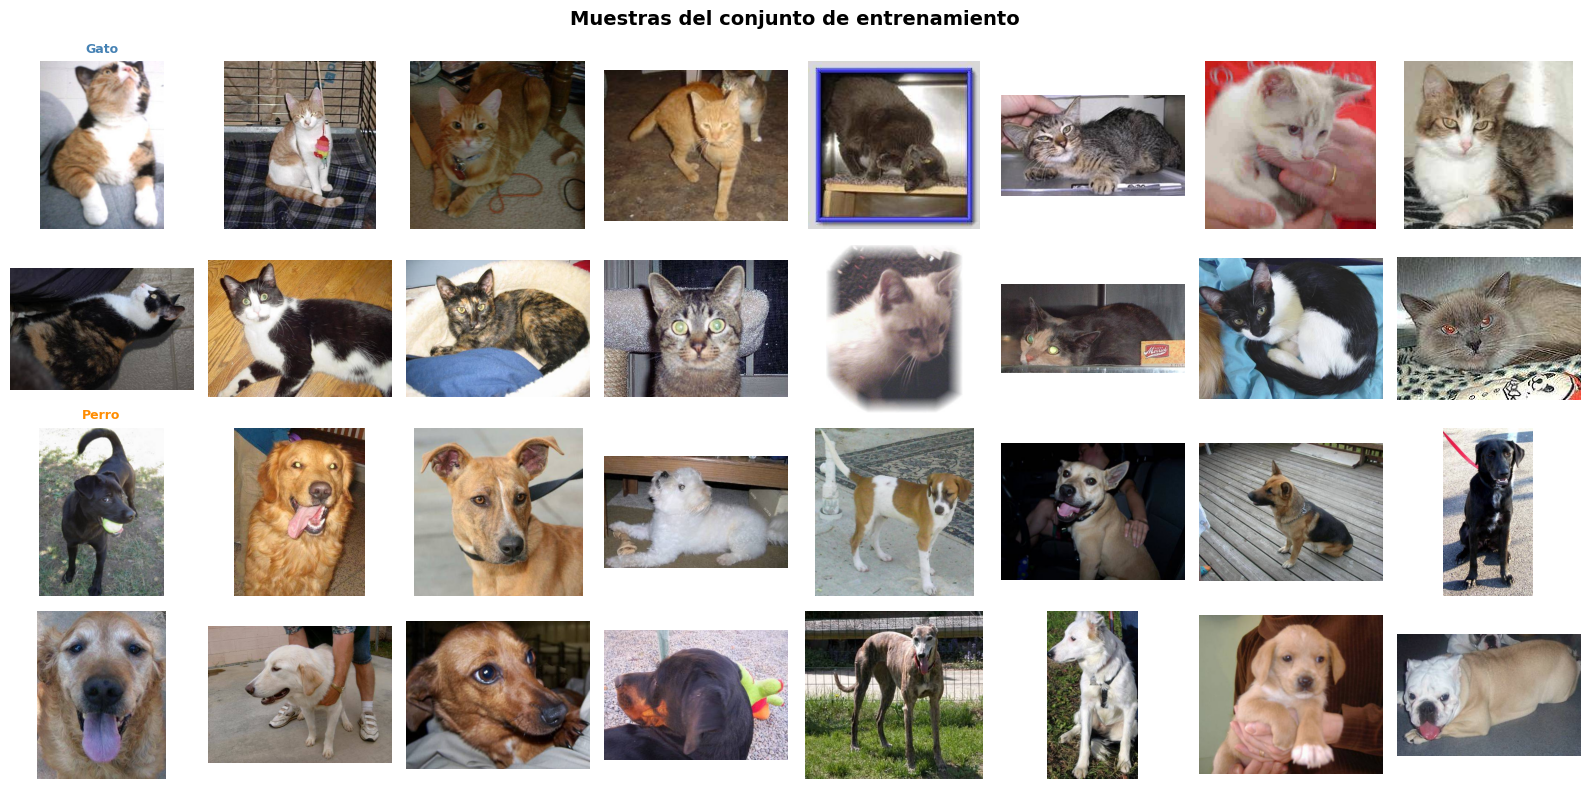

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle("Muestras del conjunto de entrenamiento", fontsize=14, fontweight="bold")

cat_files = sorted((new_base_dir / "train" / "cat").glob("*.jpg"))
dog_files = sorted((new_base_dir / "train" / "dog").glob("*.jpg"))

sample_cats = random.sample(cat_files, 16)
sample_dogs = random.sample(dog_files, 16)

for i, ax in enumerate(axes[:2].flat):
    img = mpimg.imread(sample_cats[i])
    ax.imshow(img)
    ax.axis("off")
    if i == 0:
        ax.set_title("Gato", fontsize=9, color="steelblue", fontweight="bold")

for i, ax in enumerate(axes[2:].flat):
    img = mpimg.imread(sample_dogs[i])
    ax.imshow(img)
    ax.axis("off")
    if i == 0:
        ax.set_title("Perro", fontsize=9, color="darkorange", fontweight="bold")

plt.tight_layout()
plt.show()

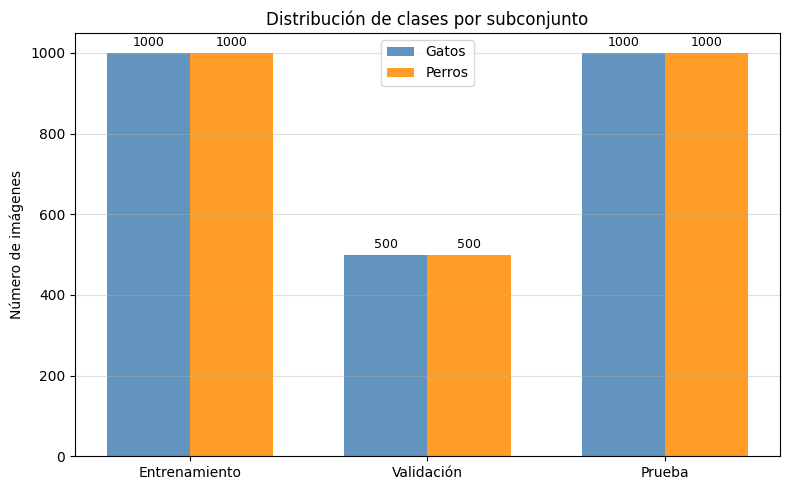

In [10]:
# Distribución de clases por subconjunto
splits   = ["train", "validation", "test"]
cats     = [len(list((new_base_dir / s / "cat").glob("*.jpg"))) for s in splits]
dogs     = [len(list((new_base_dir / s / "dog").glob("*.jpg"))) for s in splits]

x = np.arange(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, cats, width, label="Gatos", color="steelblue",  alpha=0.85)
bars2 = ax.bar(x + width/2, dogs, width, label="Perros", color="darkorange", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(["Entrenamiento", "Validación", "Prueba"])
ax.set_ylabel("Número de imágenes")
ax.set_title("Distribución de clases por subconjunto")
ax.legend()
ax.grid(axis="y", alpha=0.4)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 4. Preparación de los datasets con Keras

Usamos `image_dataset_from_directory` de Keras para cargar las imágenes directamente desde el sistema de archivos, redimensionándolas a 180×180 píxeles y dividiéndolas en lotes (*batches*) de 32.

In [11]:
from tensorflow.keras.utils import image_dataset_from_directory

IMG_SIZE   = (180, 180)
BATCH_SIZE = 32

train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Nombres de clases:", train_dataset.class_names)

# Verificar forma de un batch
for X_batch, y_batch in train_dataset.take(1):
    print(f"Forma del batch de imágenes  : {X_batch.shape}  (dtype: {X_batch.dtype})")
    print(f"Forma del batch de etiquetas : {y_batch.shape}")

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.
Nombres de clases: ['cat', 'dog']
Forma del batch de imágenes  : (32, 180, 180, 3)  (dtype: <dtype: 'float32'>)
Forma del batch de etiquetas : (32,)


## 5. Definición de la CNN

Construimos una CNN con la **API Funcional** de Keras. La arquitectura se compone de:

- **Capa de reescalado** (`Rescaling(1./255)`): normaliza los valores de píxel del rango [0, 255] al rango [0, 1].
- **Bloques convolucionales**: pares de `Conv2D + ReLU` seguidos de `MaxPooling2D`, que extraen características y reducen la resolución espacial progresivamente.
- **Capa `Flatten`**: convierte el tensor 3D de características en un vector 1D.
- **Capa `Dense` de salida** con activación **sigmoide**: produce una probabilidad escalar entre 0 y 1 (0 = gato, 1 = perro).

> 💡 **Nota**: se usa **entropía cruzada binaria** como función de pérdida porque es un problema de clasificación binaria (dos clases).

In [12]:
from tensorflow.keras import layers

inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32,  kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64,  kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Total de parámetros            : {total_params:,}")
print(f"Parámetros entrenables         : {trainable_params:,}")

Total de parámetros            : 991,041
Parámetros entrenables         : 991,041


In [14]:
model.compile(
    loss="binary_crossentropy",
    optimizer="rmsprop",
    metrics=["accuracy"]
)
print("Modelo compilado exitosamente.")

Modelo compilado exitosamente.


---

### <font color="blue">**Ejercicio 1.** Preguntas de reflexión sobre la arquitectura y los datos</font>

<font color="green">1. ¿Por qué la capa `Rescaling(1./255)` está incluida dentro del modelo en lugar de aplicarla antes de cargar los datos? ¿Qué ventaja tiene este enfoque?</font>

<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
Al incluir la normalización como parte del grafo del modelo, cualquier imagen que se le pase al modelo (durante entrenamiento, validación, prueba o producción) se normaliza de forma automática y consistente. Esto evita el error común de normalizar las imágenes en el preprocesamiento del conjunto de entrenamiento pero olvidarlo al hacer inferencia en producción. Además, el modelo es autónomo: no necesita que el usuario recuerde normalizar los datos externamente.
</p>
</details>

---

<font color="green">2. El número de filtros en las capas convolucionales aumenta progresivamente (32 → 64 → 128 → 256 → 256). ¿Por qué se sigue esta estrategia en la mayoría de las CNN modernas?</font>

<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
Las primeras capas convolucionales aprenden características de bajo nivel y simples (bordes, colores, texturas básicas), que son pocas y se pueden representar con pocos filtros. A medida que se avanza en la red, el campo receptivo aumenta y las capas aprenden combinaciones más abstractas y complejas de características (orejas, ojos, texturas de pelaje), que requieren más filtros para representarse adecuadamente. Al mismo tiempo, MaxPooling va reduciendo las dimensiones espaciales, por lo que aumentar los filtros compensa esa reducción y mantiene la capacidad representativa de la red.
</p>
</details>

---

<font color="green">3. La última capa usa activación **sigmoide** con un solo nodo en lugar de **softmax** con dos nodos. ¿Son equivalentes? ¿Cuándo preferirías uno u otro?</font>

<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
Para clasificación binaria son matemáticamente equivalentes: sigmoid con un nodo produce la probabilidad de la clase positiva (perro), mientras que softmax con dos nodos produce dos probabilidades que suman 1. La convención con sigmoid + binary_crossentropy es más compacta y eficiente para dos clases. Cuando hay tres o más clases se usa softmax + categorical_crossentropy (o sparse_categorical_crossentropy). Para dos clases ambos son correctos, pero sigmoid es preferible por ser más directo.
</p>
</details>

## 6. Entrenamiento del modelo

Usamos el callback `ModelCheckpoint` para guardar automáticamente la mejor versión del modelo (según la pérdida de validación) durante el entrenamiento. Esto nos protege contra el sobreajuste al asegurarnos de restaurar los pesos óptimos.

In [15]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 228ms/step - accuracy: 0.5150 - loss: 0.7107 - val_accuracy: 0.5460 - val_loss: 0.6909
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.5515 - loss: 0.6984 - val_accuracy: 0.5000 - val_loss: 0.6822
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.6170 - loss: 0.6542 - val_accuracy: 0.6430 - val_loss: 0.6298
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.6565 - loss: 0.6129 - val_accuracy: 0.6320 - val_loss: 0.6227
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.6815 - loss: 0.5855 - val_accuracy: 0.6600 - val_loss: 0.6032
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.7050 - loss: 0.5619 - val_accuracy: 0.6330 - val_loss: 0.6396
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.7275 - loss: 0.5371 - val_accuracy: 0.7050 - val_loss: 0.5604
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.7545 - loss: 0.5025 - val_accuracy: 0.7130 -

## 7. Visualización del historial de entrenamiento

Las curvas de entrenamiento y validación son una herramienta fundamental para diagnosticar el comportamiento del modelo. Una brecha creciente entre ambas curvas es la señal clásica de **sobreajuste** (*overfitting*).

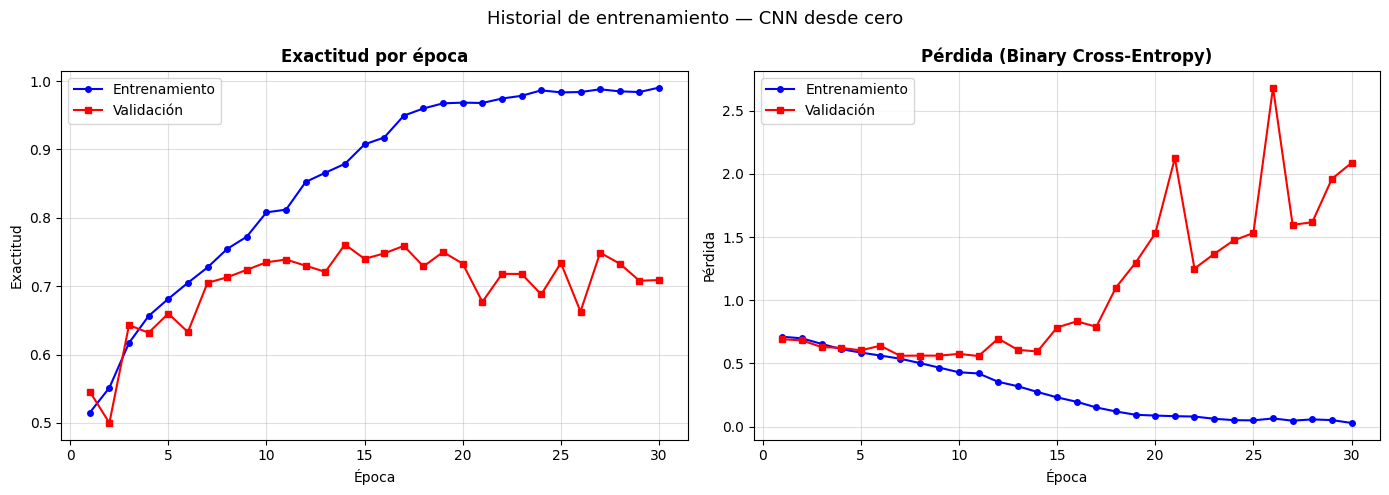

In [16]:
accuracy     = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss         = history.history["loss"]
val_loss     = history.history["val_loss"]
epochs       = range(1, len(accuracy) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Exactitud ---
axes[0].plot(epochs, accuracy,     "bo-", label="Entrenamiento", markersize=4)
axes[0].plot(epochs, val_accuracy, "rs-", label="Validación",    markersize=4)
axes[0].set_title("Exactitud por época",         fontsize=12, fontweight="bold")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Exactitud")
axes[0].legend()
axes[0].grid(alpha=0.4)

# --- Pérdida ---
axes[1].plot(epochs, loss,     "bo-", label="Entrenamiento", markersize=4)
axes[1].plot(epochs, val_loss, "rs-", label="Validación",    markersize=4)
axes[1].set_title("Pérdida (Binary Cross-Entropy)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Pérdida")
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.suptitle("Historial de entrenamiento — CNN desde cero", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Evaluación final en el conjunto de prueba

Cargamos el mejor modelo guardado (el que obtuvo la menor pérdida de validación) y lo evaluamos sobre el conjunto de prueba, que el modelo **nunca ha visto** durante el entrenamiento.

In [17]:
best_model = keras.models.load_model("convnet_from_scratch.keras")
test_loss, test_acc = best_model.evaluate(test_dataset, verbose=0)
print(f"Pérdida en prueba  : {test_loss:.4f}")
print(f"Exactitud en prueba: {test_acc:.4f}  ({test_acc*100:.2f}%)")

Pérdida en prueba  : 0.5748
Exactitud en prueba: 0.7280  (72.80%)


## 9. Visualización de predicciones

Visualizamos las predicciones del modelo sobre un lote del conjunto de prueba. Las predicciones correctas se muestran en  <font color="green">**verde**</font>  y las incorrectas en <font color="red">**rojo**</font> .

In [18]:
class_names = test_dataset.class_names  # ['cat', 'dog']

X_sample, y_sample = next(iter(test_dataset))
preds_prob = best_model.predict(X_sample, verbose=0).flatten()
preds      = (preds_prob > 0.5).astype(int)

fig, axes = plt.subplots(4, 8, figsize=(16, 9))
fig.suptitle("Predicciones del modelo — conjunto de prueba\n(verde = correcto | rojo = incorrecto)",
             fontsize=13, fontweight="bold")

for i, ax in enumerate(axes.flat):
    if i >= len(X_sample):
        ax.axis("off")
        continue
    img = X_sample[i].numpy().astype("uint8")
    ax.imshow(img)
    ax.axis("off")
    color = "green" if preds[i] == y_sample[i].numpy() else "red"
    pred_name = class_names[preds[i]]
    real_name = class_names[y_sample[i].numpy()]
    ax.set_title(f"P: {pred_name}\nR: {real_name}", fontsize=7, color=color)

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 10. Matriz de confusión

La matriz de confusión nos permite ver no solo cuántos errores comete el modelo, sino también **qué tipo de errores** comete: falsos positivos (predice perro cuando es gato) y falsos negativos (predice gato cuando es perro).

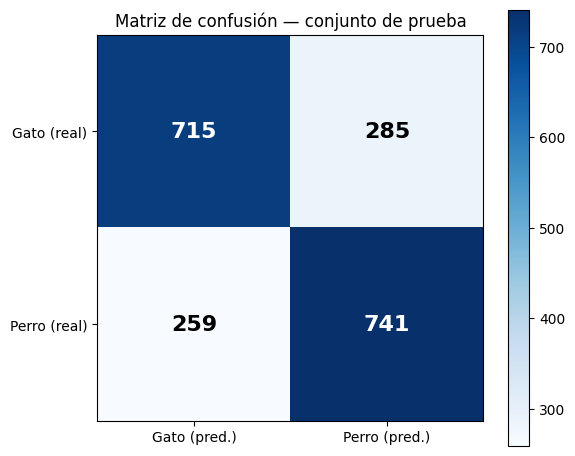


Reporte de clasificación:
              precision    recall  f1-score   support

        Gato       0.73      0.71      0.72      1000
       Perro       0.72      0.74      0.73      1000

    accuracy                           0.73      2000
   macro avg       0.73      0.73      0.73      2000
weighted avg       0.73      0.73      0.73      2000



In [19]:
from sklearn.metrics import confusion_matrix, classification_report

all_preds, all_labels = [], []

for X_batch, y_batch in test_dataset:
    probs  = best_model.predict(X_batch, verbose=0).flatten()
    all_preds.extend((probs > 0.5).astype(int).tolist())
    all_labels.extend(y_batch.numpy().tolist())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Gato (pred.)", "Perro (pred.)"], fontsize=10)
ax.set_yticklabels(["Gato (real)",  "Perro (real)"],  fontsize=10)
ax.set_title("Matriz de confusión — conjunto de prueba", fontsize=12)

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                fontsize=16, fontweight="bold", color=color)

plt.tight_layout()
plt.show()

print("\nReporte de clasificación:")
print(classification_report(all_labels, all_preds, target_names=["Gato", "Perro"]))

## 11. Análisis del sobreajuste

Con tan pocas imágenes de entrenamiento (2 000), es esperable que el modelo sufra **sobreajuste**: aprende los datos de entrenamiento de memoria pero generaliza mal. La siguiente gráfica resume visualmente la brecha entre entrenamiento y validación.

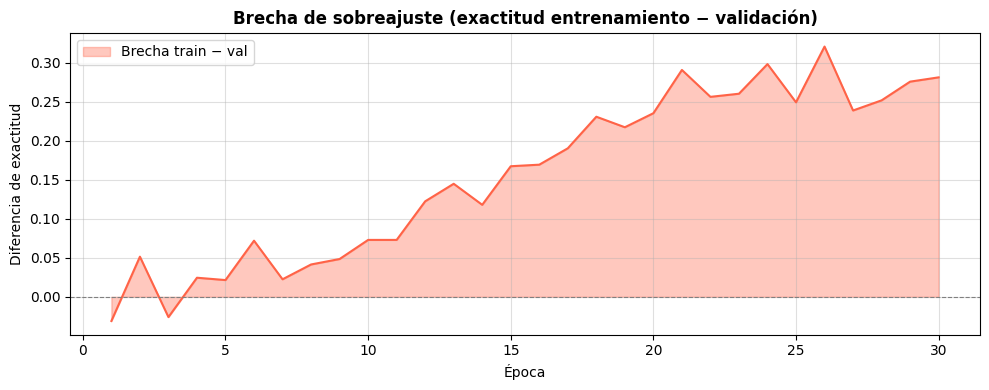

In [20]:
gap = [tr - va for tr, va in zip(accuracy, val_accuracy)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(epochs, gap, alpha=0.35, color="tomato", label="Brecha train − val")
ax.plot(epochs, gap, color="tomato", linewidth=1.5)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Brecha de sobreajuste (exactitud entrenamiento − validación)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Época")
ax.set_ylabel("Diferencia de exactitud")
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

---

### <font color="blue">**Ejercicio 2.** Análisis del sobreajuste</font>

<font color="green">Observa las curvas de entrenamiento/validación y la gráfica de brecha de sobreajuste, luego responde:</font>

1. ¿A partir de qué época aproximada comienza a manifestarse el sobreajuste? ¿Cómo lo identificas en la gráfica?
2. La exactitud de entrenamiento sigue subiendo mientras la de validación se estabiliza o baja. ¿Qué implica esto sobre la capacidad del modelo?
3. El callback `ModelCheckpoint` guarda el modelo cuando `val_loss` es mínima. ¿Por qué se usa la pérdida de validación y no la exactitud de validación como criterio de guardado?

<details>
<summary>👉 Clic para mostrar/ocultar respuesta orientadora</summary>
<p>
El sobreajuste típicamente se manifiesta cuando la curva de exactitud de entrenamiento sigue subiendo mientras la de validación se aplana o disminuye (gráfica de exactitud), o cuando la pérdida de validación comienza a subir mientras la de entrenamiento sigue bajando (gráfica de pérdida). Con solo 2 000 imágenes, la red tiene suficiente capacidad (parámetros) como para memorizar el conjunto de entrenamiento. Se usa val_loss como criterio de guardado porque la pérdida es más informativa que la exactitud: captura la confianza del modelo en sus predicciones, no solo si acierta o no.
</p>
</details>

---

### <font color="blue">**Ejercicio 3.** Mejora el modelo: Data Augmentation</font>

<font color="green">Una estrategia efectiva para reducir el sobreajuste cuando se tienen pocos datos es el **aumento de datos** (*data augmentation*): aplicar transformaciones aleatorias a las imágenes de entrenamiento para aumentar artificialmente la diversidad del dataset.</font>

Agrega un bloque de aumento de datos al inicio del modelo usando las capas de Keras:

```python
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])
```

Incorpora este bloque justo después de la capa `Input` y antes de `Rescaling`. Entrena el nuevo modelo y compara las curvas de entrenamiento con las del modelo original.

Responde:
1. ¿Se redujo el sobreajuste? ¿Cómo lo evidencian las curvas?
2. ¿Mejoró la exactitud en el conjunto de prueba?

In [ ]:
# =============================================
# TU CÓDIGO AQUÍ: Modelo con Data Augmentation
# =============================================

# Ejemplo de punto de partida:
# data_augmentation = keras.Sequential([
#     layers.RandomFlip("horizontal"),
#     layers.RandomRotation(0.1),
#     layers.RandomZoom(0.2),
# ])
#
# inputs = keras.Input(shape=(180, 180, 3))
# x = data_augmentation(inputs)       # <-- Agrega aquí
# x = layers.Rescaling(1./255)(x)
# ... (mismas capas convolucionales)
# outputs = layers.Dense(1, activation="sigmoid")(x)
# model_aug = keras.Model(inputs=inputs, outputs=outputs)
#
# model_aug.compile(loss="binary_crossentropy", optimizer="rmsprop", metrics=["accuracy"])
#
# callbacks_aug = [
#     keras.callbacks.ModelCheckpoint(
#         filepath="convnet_augmented.keras",
#         save_best_only=True,
#         monitor="val_loss")
# ]
#
# history_aug = model_aug.fit(
#     train_dataset,
#     epochs=50,     # Más épocas porque el modelo aprende más lentamente
#     validation_data=validation_dataset,
#     callbacks=callbacks_aug
# )

In [ ]:
# Celda para graficar y comparar ambos modelos
# (Completar solo si se implementó el Ejercicio 3)

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# ...
# plt.show()